<a href="https://colab.research.google.com/github/Melisaoktavia/pratikum3_minggu6/blob/main/PCD_MGG6_P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PRAKTIKUM 6.3: MOTION BLUR ESTIMATION DAN DEBLURRING
Estimated Length: 125
Estimated Angle: 117.0


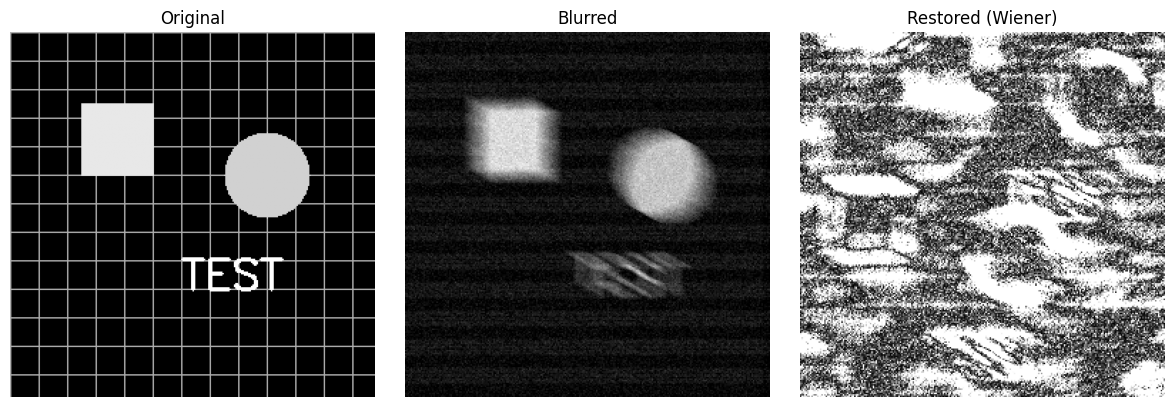

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import signal

# Jika di Jupyter / Colab
%matplotlib inline

def praktikum_6_3():
    """
    Motion blur estimation dan teknik deblurring
    """
    print("\nPRAKTIKUM 6.3: MOTION BLUR ESTIMATION DAN DEBLURRING")
    print("=" * 60)

    # Generate motion blurred image
    def create_motion_blurred_image():
        img = np.zeros((256, 256), dtype=np.uint8)

        # Create detailed pattern
        for i in range(0, 256, 20):
            cv2.line(img, (i, 0), (i, 255), 150, 1)
            cv2.line(img, (0, i), (255, i), 150, 1)

        # Add objects
        cv2.rectangle(img, (50, 50), (100, 100), 200, -1)
        cv2.circle(img, (180, 100), 30, 180, -1)

        # Text
        cv2.putText(img, 'TEST', (120, 180),
                   cv2.FONT_HERSHEY_SIMPLEX,
                   1, 220, 2)

        # Motion blur PSF
        length = 21
        angle = 30

        psf = np.zeros((length, length))
        center = length // 2
        angle_rad = np.deg2rad(angle)

        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(psf, (x_start, y_start), (x_end, y_end), 1, 1)
        psf = psf / np.sum(psf)

        blurred = cv2.filter2D(img.astype(float), -1, psf)

        noise = np.random.normal(0, 10, blurred.shape)
        blurred_noisy = np.clip(blurred + noise, 0, 255)

        return img, blurred_noisy.astype(np.uint8), psf

    def estimate_motion_blur_parameters(image):
        edges = cv2.Canny(image, 50, 150)

        lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=100)

        angles = []
        if lines is not None:
            for line in lines[:5]:
                rho, theta = line[0]
                angles.append(np.degrees(theta))

        if angles:
            estimated_angle = np.mean(angles) % 180
        else:
            estimated_angle = 0

        autocorr = signal.correlate2d(image, image, mode='same')
        autocorr = autocorr / np.max(autocorr)

        center = autocorr.shape[0] // 2
        profile = autocorr[center, :]

        half_max = 0.5
        above_half = profile > half_max

        if np.any(above_half):
            indices = np.where(above_half)[0]
            fwhm = indices[-1] - indices[0]
            estimated_length = fwhm // 2
        else:
            estimated_length = 15

        return estimated_length, estimated_angle

    def motion_deblur_wiener(image, length, angle, K=0.001):
        psf_size = max(31, 2 * length + 1)
        psf = np.zeros((psf_size, psf_size))

        center = psf_size // 2
        angle_rad = np.deg2rad(angle)

        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(psf, (x_start, y_start), (x_end, y_end), 1, 1)
        psf = psf / np.sum(psf)

        pad_size = psf_size // 2

        padded = cv2.copyMakeBorder(
            image,
            pad_size,
            pad_size,
            pad_size,
            pad_size,
            cv2.BORDER_REFLECT
        )

        G = np.fft.fft2(padded.astype(float))

        psf_padded = np.zeros_like(padded, dtype=float)

        psf_center = psf_size // 2
        pad_center = padded.shape[0] // 2

        y_start = pad_center - psf_center
        x_start = pad_center - psf_center

        psf_padded[
            y_start:y_start+psf_size,
            x_start:x_start+psf_size
        ] = psf

        psf_padded = np.fft.ifftshift(psf_padded)

        H = np.fft.fft2(psf_padded)
        H_conj = np.conj(H)
        H_abs_sq = np.abs(H) ** 2

        W = H_conj / (H_abs_sq + K)

        F_hat = G * W

        restored_padded = np.abs(np.fft.ifft2(F_hat))

        restored = restored_padded[
            pad_size:-pad_size,
            pad_size:-pad_size
        ]

        return np.clip(restored, 0, 255).astype(np.uint8)

    # Generate data
    original, blurred, true_psf = create_motion_blurred_image()

    estimated_length, estimated_angle = \
        estimate_motion_blur_parameters(blurred)

    print("Estimated Length:", estimated_length)
    print("Estimated Angle:", estimated_angle)

    # Deblur
    restored = motion_deblur_wiener(
        blurred,
        estimated_length,
        estimated_angle
    )

    # Visualisasi
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(blurred, cmap='gray')
    plt.title("Blurred")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(restored, cmap='gray')
    plt.title("Restored (Wiener)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return original, blurred, restored

# Jalankan
original_motion, blurred_motion, restored_motion = praktikum_6_3()